<a href="https://colab.research.google.com/github/ohki-yu0225/toukei_1B_5/blob/main/260515_notebook_5_ans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 内容

- 広がりの尺度
- 散布図と相関係数

### データ

- 解析対象：世界のサッカー選手のデータ (2022/2023 シーズン)
- 出典：EA Sports FC 24 complete player dataset (https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset?select=male_players.csv)


### Contents

- Measures of dispersion
- Scatter plots and Correlation coefficients

### Data

- Data of world football players (2022/2023 season)
- Source: EA Sports FC 24 complete player dataset (https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset? select=male_players.csv)

## データ分析の準備


## Preparation of data analysis


In [72]:
# 'pandas', 'numpy', 'matplotlib.pyplot', 'japanize_matplotlib'をインポートする。
# Import 'pandas', 'numpy', 'matplotlib.pyplot', and 'japanize_matplotlib'.
# Pandas -> pd
# Numpy -> np
# matplotlib.pyplot -> plt
!pip install japanize_matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [73]:
# 'sample_5.csv'を読み込んで、変数'data'に代入し、最初の10行を表示する。
# Read 'sample_5.csv', assign it to the variable 'data' and display the first 10 rows.
data = pd.read_csv("sample_5.csv")
data.head(10)

,Name,Value,Wage,Age,Height,Weight,Club,League,Nationality,Value_JPY,Wage_JPY_y
0,K. Mbappé,181500000.0,230000.0,24,182,75,Paris Saint Germain,Ligue 1,France,299.475,19.7340
1,E. Haaland,185000000.0,340000.0,22,195,94,Manchester City,Premier League,Norway,305.250,29.1720
2,K. De Bruyne,103000000.0,350000.0,32,181,75,Manchester City,Premier League,Belgium,169.950,30.0300
3,L. Messi,41000000.0,23000.0,36,169,67,Inter Miami,Major League Soccer,Argentina,67.650,1.9734
4,K. Benzema,51000000.0,95000.0,35,185,81,Al Ittihad,Pro League,France,84.150,8.1510
5,R. Lewandowski,58000000.0,340000.0,34,185,81,FC Barcelona,La Liga,Poland,95.700,29.1720
6,T. Courtois,63000000.0,250000.0,31,199,96,Real Madrid,La Liga,Belgium,103.950,21.4500
7,H. Kane,119500000.0,170000.0,29,188,85,FC Bayern München,Bundesliga,England,197.175,14.5860
8,Vini Jr.,158500000.0,310000.0,22,176,73,Real Madrid,La Liga,Brazil,261.525,26.5980
9,Alisson,77500000.0,180000.0,30,193,91,Liverpool,Premier League,Brazil,127.875,15.4440


Name: 名前 <br>
Value: 市場価値（ユーロ[EUR]）<br>
Wage: 週給（ユーロ[EUR/Week]）<br>
Age: 年齢<br>
Height: 身長(cm)<br>
Weight: 体重(kg)<br>
Club: 所属クラブ<br>
League: 所属リーグ<br>
Nationality: 国籍<br>
Value_JPY: 市場価値（1億円[100M JPY]）<br>
Wage_JPY_y: 年俸（1億円[100M JPY/Year]）


## 広がりの尺度の計算

### 分散と標準偏差

各データの平均値からのばらつき（偏差）でデータの広がりを表現することもある。代表的なものとして分散と標準偏差がある。分散には母分散と標本分散があるが、ここでは標本分散を計算する。分散は`numpy`の`var`関数で計算する。標準偏差は分散の平方根であり、`numpy`の`std`関数で計算できる。

---

```Python
np.var(a)
```

---


### Variance and Standard Deviation

The spread of data can also be expressed in terms of the variation (deviation) from the mean of each of the data. Typical examples are variance and standard deviation. Variance has two types: population variance and sample variance, and sample variance is calculated in this class. Variance is calculated with the `var` function of `numpy`. The standard deviation is the square root of the variance and can be calculated with the `std` function of `numpy`.

---

```Python
np.var(a)
```

---

In [102]:
# 身長の平均値を計算する。
# Calculate the mean of height.
h_mean = data["Height"].mean()
print(f"身長の平均値：{h_mean}cm")

身長の平均値：181.7049315068493cm


In [103]:
# 練習 体重の平均値を計算する。
# Exercise 3 Calculate the mean of weight.
w_mean = data["Weight"].mean()
print(f"体重の平均値：{w_mean}kg")

体重の平均値：75.21046575342466kg


In [104]:
# 身長の分散と標準偏差を求める。
# Calculate the variance and standard deviation for height.
h_var = data["Height"].var()
h_std = data["Height"].std()
print(f"身長の分散：{h_var}cm^2")
print(f"身長の標準偏差：{h_std}cm")

身長の分散：47.15732676663902cm^2
身長の標準偏差：6.867119248028173cm


In [77]:
# 練習 体重の分散と標準偏差を求める。
# Exercise 4 Calculate the variance and standard deviation for weight.
w_var = data["Weight"].var()
w_std = data["Weight"].std()
print(f"体重の分散：{w_var}kg^2")
print(f"体重の標準偏差：{w_std}kg")

体重の分散：48.746772659786075kg^2
体重の標準偏差：6.981888903426212kg


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1747/1534776895.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(h_mean + h_std, color="b", ls="--", label="平均値$\pm$標準偏差")
/tmp/ipykernel_1747/1534776895.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(h_mean + 2 * h_std, color="m", ls="--", label="平均値$\pm$2標準偏差")


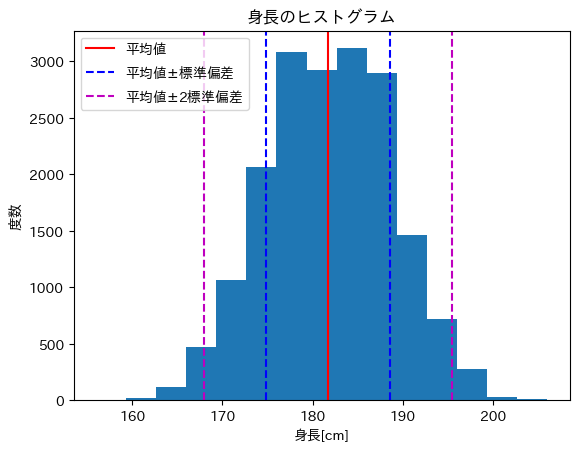

In [105]:
# 身長のヒストグラムを作成し、平均値と平均値+-標準偏差、平均値+-2*標準偏差を図示する。
# Create a histogram of height and illustrate the mean value, mean +- standard deviation, and mean +- 2 * standard deviation.
plt.hist(data["Height"], bins=15)
plt.title("身長のヒストグラム")
plt.xlabel("身長[cm]")
plt.ylabel("度数")

# 平均値を図示(mean)
plt.axvline(h_mean, color="r", label="平均値")

# 平均値+-標準偏差を図示(mean +- standard deviation)
plt.axvline(h_mean + h_std, color="b", ls="--", label="平均値$\pm$標準偏差")
plt.axvline(h_mean - h_std, color="b", ls="--")

# 平均値+-2*標準偏差を図示(mean +- 2 * standard deviation)
plt.axvline(h_mean + 2 * h_std, color="m", ls="--", label="平均値$\pm$2標準偏差")
plt.axvline(h_mean - 2 * h_std, color="m", ls="--")
plt.legend()

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1747/239274118.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(w_mean + w_std, color="b", ls="--", label="平均値$\pm$標準偏差")
/tmp/ipykernel_1747/239274118.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(w_mean + 2 * w_std, color="m", ls="--", label="平均値$\pm$2標準偏差")


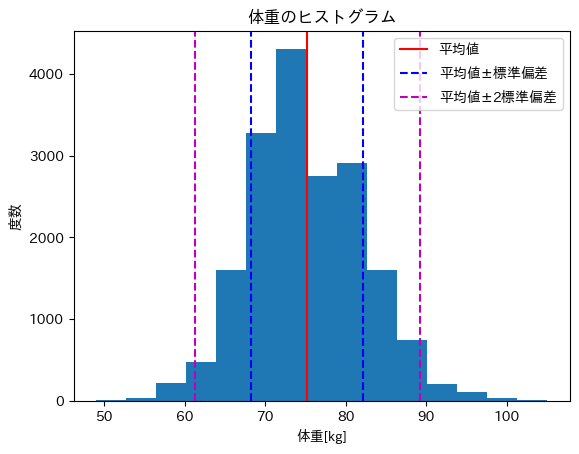

In [106]:
# 練習 体重のヒストグラムを作成し、平均値と平均値+標準偏差、平均値-標準偏差を図示する。
# Exercise 5 Create a histogram of weight and illustrate the mean value, mean +- standard deviation, and mean +- 2 * standard deviation.
plt.hist(data["Weight"], bins=15)
plt.title("体重のヒストグラム")
plt.xlabel("体重[kg]")
plt.ylabel("度数")

# 平均値を図示(mean)
plt.axvline(w_mean, color="r", label="平均値")

# 平均値+-標準偏差を図示(mean +- standard deviation)
plt.axvline(w_mean + w_std, color="b", ls="--", label="平均値$\pm$標準偏差")
plt.axvline(w_mean - w_std, color="b", ls="--")

# 平均値+-2*標準偏差を図示(mean +- 2 * standard deviation)
plt.axvline(w_mean + 2 * w_std, color="m", ls="--", label="平均値$\pm$2標準偏差")
plt.axvline(w_mean - 2 * w_std, color="m", ls="--")
plt.legend()

### 標準化

性質の異なる変数の分布を比較するときに、分布の平均値を0、分散および標準偏差を1にする標準化が行われる。標準化は次の式で行われる。標準化された値をZ-scoreとも呼ぶ。

$$（標準化された値）=\frac{（元データの値）-（平均値）}{（標準偏差）}$$

### Standardization

When comparing distributions of variables of different nature, standardization is performed to set the mean of the distributions to 0 and the variance and standard deviation to 1. Standardization is performed with the following equation.The standardized value is also called Z-score.

$$(\text{Standardized value})=\frac{(\text{Original value})-(\text{Mean})}{(\text{Standard deviation})}$$

In [109]:
# 身長を平均値を0、分散・標準偏差を1に標準化する。
# Standardize height to 0 for mean and 1 for variance/standard deviation.
data["Height_s"] = (data["Height"] - h_mean) / h_std
h_mean_s = data["Height_s"].mean()
h_var_s = data["Height_s"].var()
h_std_s = data["Height_s"].std()
print(f"標準化された身長の平均値：{h_mean_s}")
print(f"標準化された身長の分散：{h_var_s}")
print(f"標準化された身長の標準偏差：{h_std_s}")

標準化された身長の平均値：1.3533405750696484e-15
標準化された身長の分散：0.9999999999999482
標準化された身長の標準偏差：0.999999999999974


In [110]:
# 練習 体重の平均値を0、分散・標準偏差を1に標準化する。
# Exercise 6 Standardize weight to 0 for mean and 1 for variance/standard deviation.
data["Weight_s"] = (data["Weight"] - w_mean) / w_std
w_mean_s = data["Weight_s"].mean()
w_var_s = data["Weight_s"].var()
w_std_s = data["Weight_s"].std()
print(f"標準化された体重の平均値：{w_mean_s}")
print(f"標準化された体重の分散：{w_var_s}")
print(f"標準化された体重の標準偏差：{w_std_s}")

標準化された体重の平均値：8.098240495238402e-17
標準化された体重の分散：1.0000547975231662
標準化された体重の標準偏差：1.0000273983862473


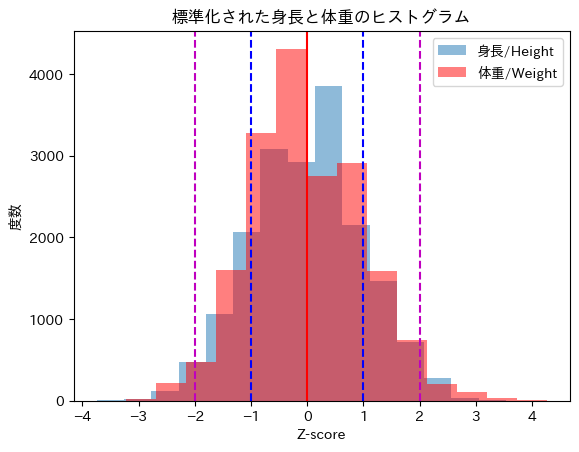

In [111]:
# 標準化された身長と体重のヒストグラムを図示する。
# Illustrate a histogram of standardized height and weight.
plt.hist(data["Height_s"], bins=15, label="身長/Height", alpha=0.5)
plt.hist(data["Weight_s"], bins=15, label="体重/Weight", facecolor="r", alpha=0.5)

plt.axvline(0, color="r")
# 平均値+-標準偏差を図示
plt.axvline(1, color="b", ls="--")
plt.axvline(-1, color="b", ls="--")
# 平均値+-2*標準偏差を図示
plt.axvline(2, color="m", ls="--")
plt.axvline(-2, color="m", ls="--")

# タイトルと軸ラベルの追加
plt.title("標準化された身長と体重のヒストグラム")
plt.xlabel("Z-score")
plt.ylabel("度数")
plt.legend()

In [112]:
# 標準化された身長が+-1および+-2の範囲に何％含まれるかを調べる。
# Calculate what percentage of standardized heights are within the +-1 and +-2 ranges.
height_s = np.array(data["Height_s"])
num_h_1s = len(height_s[(height_s > -1) & (height_s < 1)])
num_h_2s = len(height_s[(height_s > -2) & (height_s < 2)])
num_h = len(height_s)
print(f"標準偏差の範囲のデータの割合：{num_h_1s/num_h*100}％")
print(f"2*標準偏差の範囲のデータの割合：{num_h_2s/num_h*100}％")

標準偏差の範囲のデータの割合：69.0027397260274％
2*標準偏差の範囲のデータの割合：96.69589041095891％


In [113]:
# 標準化された体重が+-1および+-2の範囲に何％含まれるかを調べる。
# Calculate what percentage of standardized weights are within the +-1 and +-2 ranges.
weight_s = np.array(data["Weight_s"])
num_w_1s = len(weight_s[(weight_s > -1) & (weight_s < 1)])
num_w_2s = len(weight_s[(weight_s > -2) & (weight_s < 2)])
num_w = len(weight_s)
print(f"標準偏差の範囲のデータの割合：{num_w_1s/num_w*100}％")
print(f"2*標準偏差の範囲のデータの割合：{num_w_2s/num_w*100}％")

標準偏差の範囲のデータの割合：68.67397260273972％
2*標準偏差の範囲のデータの割合：95.40821917808219％


（参考）チェビシェフの定理：分布の広がりとデータ数の関係について、どのような分布に対しても一般的に次の法則が成り立つ。
- 平均値から2*標準偏差の範囲に少なくとも75%のデータが含まれる。
- 平均値から3*標準偏差の範囲に少なくとも88.89%のデータが含まれる。

(Reference) Chebyshev's theorem: The following law generally holds for any distribution regarding the relationship between the spread of the distribution and the number of data.
- At least 75% of the data are contained within 2* standard deviations from the mean.
- At least 88.89% of the data are contained within 3* standard deviations from the mean.

### 四分位範囲・四分位偏差

データの分布の広がりを表す尺度として、四分位範囲と四分位偏差や分散と標準偏差が使われる。四分位範囲は、四分位数を求めて、第 3 四分位数から第 1 四分位数を引くことで求める。四分位偏差は四分位範囲の半分である。

### Quartile Range and Quartile Deviation

Quartile range and quartile deviation or variance and standard deviation are used as measures of the spread of the distribution of data. The quartile range is obtained by subtracting the first quartile from the third quartile.

In [101]:
# 身長の四分位数を求める。
# Calculate the quartiles of height.
h_q1 = data["Height"].quantile(0.25)
h_q2 = data["Height"].quantile(0.50)
h_q3 = data["Height"].quantile(0.75)
print(f"身長の第1四分位数(1st quartile)：{h_q1}cm")
print(f"身長の第2四分位数(2nd quartile)：{h_q2}cm")
print(f"身長の第3四分位数(3rd quartile)：{h_q3}cm")

身長の第1四分位数(1st quartile)：177.0cm
身長の第2四分位数(2nd quartile)：182.0cm
身長の第3四分位数(3rd quartile)：187.0cm


In [86]:
# 身長の四分位範囲と四分位偏差を求める。
# Calculate the quartile range and quartile deviation for height.
h_iqr = h_q3 - h_q1
h_iqd = h_iqr / 2
print(f"身長の四分位範囲(Quartile range)：{h_iqr}cm")
print(f"身長の四分位偏差(Quartile deviation)：{h_iqd}cm")

身長の四分位範囲(Quartile range)：10.0cm
身長の四分位偏差(Quartile deviation)：5.0cm


In [87]:
# 練習 体重の四分位数を求めてください。
# Exercise 8: Calculate the quartiles of weight.
w_q1 = data["Weight"].quantile(0.25)
w_q2 = data["Weight"].quantile(0.50)
w_q3 = data["Weight"].quantile(0.75)
print(f"体重の第1四分位数(1st quartile)：{w_q1}kg")
print(f"体重の第2四分位数(2nd quartile)：{w_q2}kg")
print(f"体重の第3四分位数(3rd quartile)：{w_q3}kg")

体重の第1四分位数(1st quartile)：70.0kg
体重の第2四分位数(2nd quartile)：75.0kg
体重の第3四分位数(3rd quartile)：80.0kg


In [88]:
# 練習 体重の四分位範囲と四分位偏差を求めてください。
# Exercise 9: Calculate the quartile range and quartile deviation for weight.
w_iqr = w_q3 - w_q1
w_iqd = w_iqr / 2
print(f"体重の四分位範囲(Quartile range)：{w_iqr}kg")
print(f"体重の四分位偏差(Quartile deviation)：{w_iqd}kg")

体重の四分位範囲(Quartile range)：10.0kg
体重の四分位偏差(Quartile deviation)：5.0kg


## 箱ひげ図

四分位範囲は箱ひげ図を用いて図示する。箱ひげ図の図示は`matplotlib.pyplot`の`boxplot`の関数を用いる。

---

```Python
plt.boxplot(a)
```

---


## Box plots

Quartile deviations are plotted using box plots. Box plots are plotted using the `boxplot` function of `matplotlib.pyplot`.

---

```Python
plt.boxplot(a)
```

---

Text(0, 0.5, 'Z-score')

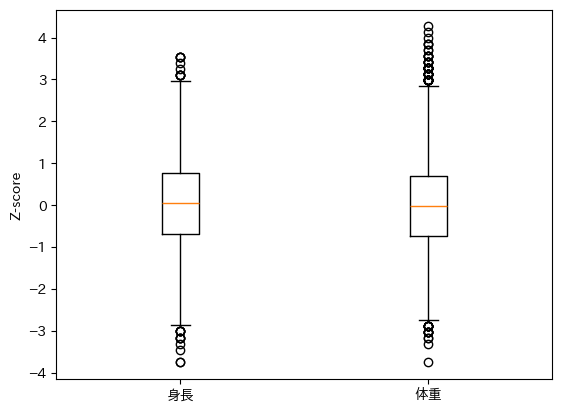

In [89]:
# 標準化された身長と体重の箱ひげ図を図示する。
# Illustrate a boxplot of standardized height and weight.
plt.boxplot([height_s, weight_s], tick_labels=["身長", "体重"])
plt.ylabel("Z-score")

## グループごとの統計量の計算・分布の比較

`df.groupby("カテゴリー変数")["量的変数"].mean()`の形でカテゴリーごとに量的変数の平均値を計算できる

## Calculation of Group-wise Statistics and Comparison of Distributions

You can calculate the mean of a quantitative variable for each category using the form df.groupby("categorical_variable")["quantitative_variable"].mean().

In [100]:
data.groupby("Nationality")["Height"].mean()

,Height
Nationality,
Albania,182.694915
Algeria,180.072464
Andorra,190.000000
Angola,180.818182
Antigua and Barbuda,179.000000
...,...
Vanuatu,180.000000
Venezuela,178.185393
Wales,182.049296


平均値（`mean()`）以外にも中央値や標準偏差など任意の統計量が計算できる。

In addition to the mean (mean()), arbitrary statistics such as the median and standard deviation can also be calculated.

In [114]:
data.groupby("Nationality")["Height"].median()

,Height
Nationality,
Albania,182.0
Algeria,180.0
Andorra,190.0
Angola,180.0
Antigua and Barbuda,178.0
...,...
Vanuatu,180.0
Venezuela,178.0
Wales,181.5


In [115]:
data.groupby("Nationality")["Height"].std()

,Height
Nationality,
Albania,6.317066
Algeria,5.819134
Andorra,NaN
Angola,6.779776
Antigua and Barbuda,1.732051
...,...
Vanuatu,NaN
Venezuela,6.957856
Wales,6.671977


グループ間でデータの分布を比較するときには，`seaborn(sns)`の`boxplot`を使うのも便利。

When comparing data distributions across groups, it is also useful to use `boxplot` in `seaborn (sns)`.

Text(0.5, 0, '国籍')

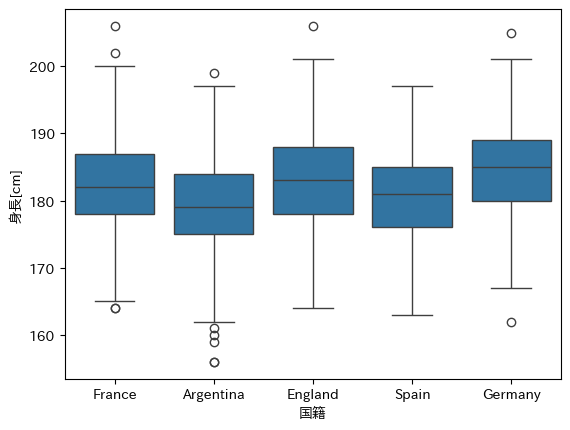

In [97]:
# 国籍がイングランド，ドイツ，スペイン，アルゼンチン，フランスの選手の身長の箱ひげ図を図示する。
# Create boxplots of player heights for players whose nationality is
# England, Germany, Spain, Argentina, or France.

import seaborn as sns

country = ["England", "Germany", "Spain", "Argentina", "France"]
data_ = data[data["Nationality"].isin(country)]
sns.boxplot(x="Nationality", y="Height", data=data_)
plt.ylabel("身長[cm]")
plt.xlabel("国籍")

## 演習課題

実習終了後に演習課題を配布するので，Pythonを用いて回答してください。記述・実行したファイルPDFとして出力し，OpenLMSで提出すること。提出締め切りは4限終了時(17:05)までとする。

In [126]:
mean_wage = data.groupby("League")["Wage_JPY_y"].mean().rename("mean")
mean_wage

,mean
League,
1. Division,0.053319
1. HNL,0.052989
2. Bundesliga,0.541594
3. Liga,0.109447
A-League,0.125627
Allsvenskan,0.132287
Bundesliga,1.398903
Championship,1.058027
Ekstraklasa,0.185341


In [125]:
median_wage = data.groupby("League")["Wage_JPY_y"].median().rename("median")
median_wage

,median
League,
1. Division,0.045045
1. HNL,0.042900
2. Bundesliga,0.429000
3. Liga,0.085800
A-League,0.081510
Allsvenskan,0.085800
Bundesliga,0.858000
Championship,0.772200
Ekstraklasa,0.171600


In [127]:
quartiles_wage = data.groupby("League")["Wage_JPY_y"].quantile([0.25, 0.5, 0.75]).unstack()
quartiles_wage.columns = ["Q1", "Q2", "Q3"]
quartiles_wage

,Q1,Q2,Q3
League,,,
1. Division,0.042900,0.045045,0.060060
1. HNL,0.042900,0.042900,0.060060
2. Bundesliga,0.257400,0.429000,0.686400
3. Liga,0.051480,0.085800,0.171600
A-League,0.047190,0.081510,0.171600
Allsvenskan,0.051480,0.085800,0.171600
Bundesliga,0.257400,0.858000,1.973400
Championship,0.343200,0.772200,1.458600
Ekstraklasa,0.085800,0.171600,0.257400


In [128]:
summary = pd.concat([mean_wage, median_wage, quartiles_wage], axis=1)
summary

,mean,median,Q1,Q2,Q3
League,,,,,
1. Division,0.053319,0.045045,0.042900,0.045045,0.060060
1. HNL,0.052989,0.042900,0.042900,0.042900,0.060060
2. Bundesliga,0.541594,0.429000,0.257400,0.429000,0.686400
3. Liga,0.109447,0.085800,0.051480,0.085800,0.171600
A-League,0.125627,0.081510,0.047190,0.081510,0.171600
Allsvenskan,0.132287,0.085800,0.051480,0.085800,0.171600
Bundesliga,1.398903,0.858000,0.257400,0.858000,1.973400
Championship,1.058027,0.772200,0.343200,0.772200,1.458600
Ekstraklasa,0.185341,0.171600,0.085800,0.171600,0.257400


In [129]:
summary_ = summary[summary.index.isin(["Premier League", "La Liga", "Bundesliga", "Serie A"])]
summary_

,mean,median,Q1,Q2,Q3
League,,,,,
Bundesliga,1.398903,0.8580,0.2574,0.8580,1.9734
La Liga,2.590282,1.7160,0.8580,1.7160,2.4882
Premier League,4.154717,3.1746,0.9438,3.1746,5.9202
Serie A,2.182820,1.4586,0.7722,1.4586,2.9172


In [130]:
summary_["IQR"] = summary_["Q3"] - summary_["Q1"]
summary_

/tmp/ipykernel_1747/3048655788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_["IQR"] = summary_["Q3"] - summary_["Q1"]


,mean,median,Q1,Q2,Q3,IQR
League,,,,,,
Bundesliga,1.398903,0.8580,0.2574,0.8580,1.9734,1.7160
La Liga,2.590282,1.7160,0.8580,1.7160,2.4882,1.6302
Premier League,4.154717,3.1746,0.9438,3.1746,5.9202,4.9764
Serie A,2.182820,1.4586,0.7722,1.4586,2.9172,2.1450


Text(0.5, 0, 'リーグ')

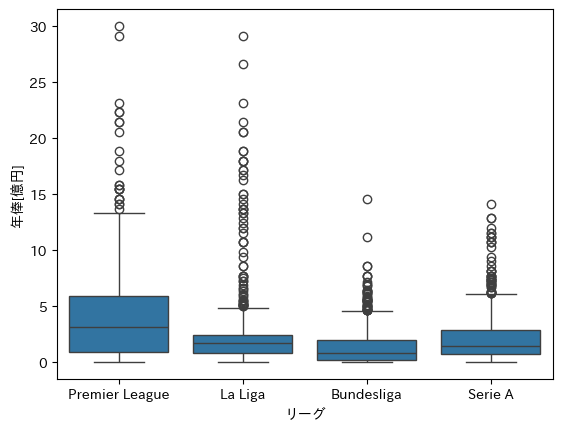

In [131]:
sns.boxplot(x="League", y="Wage_JPY_y", data=data[data["League"].isin(["Premier League", "La Liga", "Bundesliga", "Serie A"])])
plt.ylabel("年俸[億円]")
plt.xlabel("リーグ")